In [1]:
""" 
IMPORTS
"""
import os
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

# --Machine learning and statistics
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import zscore

In [2]:
""" IMPORTANT PATHS """
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/'
base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'

In [3]:
def filter_sequences(all_sequences):
    print(str(len(all_sequences.mouse_name.unique())) + str(' mice in total'))
    print(str(len(all_sequences.session.unique())) + str(' sessions in total'))

    # FIX: Use drop=True to avoid creating 'index' column
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
    print(str(len(all_sequences['session'].unique())) + str(' sessions after removing bad sessions'))

    # Filter out mice without enough sessions
    session_count = all_sequences[['mouse_name', 'session']].drop_duplicates().groupby(['mouse_name'])['session'].count().reset_index()
    multi_sess_mice = session_count.loc[session_count['session']>2, 'mouse_name']

    # FIX: Use drop=True here too
    all_sequences = all_sequences.loc[all_sequences['mouse_name'].isin(multi_sess_mice)].reset_index(drop=True)
    print(str(len(multi_sess_mice)) + str(' mice with at least 3 sessions'))
    print(str(len(all_sequences['session'].unique())) + str(' remaining sessions'))

    # Validation
    assert 'index' not in all_sequences.columns, "ERROR: 'index' column created by reset_index!"
    print("✓ Data preparation validated")
    return all_sequences

In [4]:
def binarize(use_sequences, n_paw_states=8, 
             keep_paw=True, keep_whisk=True, keep_lick=True):
    """
    Binarizes behavioral sequence data dynamically based on the number of paw states.
    Automatically infers feature dimensions based on the requested combination.
    
    Parameters:
    -----------
    use_sequences : np.ndarray
        Array of shape (n_trials, timesteps) containing encoded integer states or NaNs.
    n_paw_states : int
        The number of possible paw states (defaults to 8).
    keep_paw : bool
        Whether to keep the binarized paw states (automatically drops reference state 1).
    keep_whisk : bool
        Whether to keep the whisking state.
    keep_lick : bool
        Whether to keep the licking state.
        
    Returns:
    --------
    binarized_reduced : np.ndarray
        The filtered sequence array.
    n_out_features : int
        The number of features per timestep in the final output array.
    """
    if not (keep_paw or keep_whisk or keep_lick):
        raise ValueError("At least one feature type (paw, whisk, or lick) must be kept.")

    # The raw decoding always requires n_paw_states + 1 (whisk) + 1 (lick) columns
    n_raw_features_per_step = n_paw_states + 2 

    n_trials = use_sequences.shape[0]
    timesteps = use_sequences.shape[1]

    binarized = np.zeros((n_trials, timesteps * n_raw_features_per_step))
    
    for t in range(timesteps):
        current_vals = use_sequences[:, t]
        nan_mask = np.isnan(current_vals)
        valid_mask = ~nan_mask
        labels_0idx = current_vals[valid_mask].astype(int)
        
        start_col = t * n_raw_features_per_step
        
        if len(labels_0idx) > 0:  
            valid_row_idx = np.arange(n_trials)[valid_mask]
            
            # 1. Fill Paw States (Cols 0 to n_paw_states-1)
            paw_indices = labels_0idx % n_paw_states
            binarized[valid_row_idx, start_col + paw_indices] = 1
            
            # 2. Fill Whisking (Col equal to n_paw_states)
            whisking_col = start_col + n_paw_states
            binarized[valid_mask, whisking_col] = ((labels_0idx // n_paw_states) % 2).astype(int)
            
            # 3. Fill Licking (Col equal to n_paw_states + 1)
            licking_col = start_col + n_paw_states + 1
            binarized[valid_mask, licking_col] = (labels_0idx // (n_paw_states * 2)).astype(int)
        
        # Set all features for this timestep to NaN where original data was NaN
        if np.any(nan_mask):
            feature_cols = slice(start_col, start_col + n_raw_features_per_step)
            binarized[nan_mask, feature_cols] = np.nan

    # Determine which columns to keep within a single timestep block
    cols_to_keep_base = []
    if keep_paw:
        # Keep all paw states EXCEPT index 1 (Paw State 2)
        cols_to_keep_base.extend([i for i in range(n_paw_states) if i != 1])
    if keep_whisk:
        cols_to_keep_base.append(n_paw_states)
    if keep_lick:
        cols_to_keep_base.append(n_paw_states + 1)

    n_out_features = len(cols_to_keep_base)

    # Expand these base indices across all timesteps
    all_cols_to_keep = []
    for t in range(timesteps):
        offset = t * n_raw_features_per_step
        all_cols_to_keep.extend([offset + c for c in cols_to_keep_base])
        
    # Slice the array to keep only the requested features
    binarized_reduced = binarized[:, all_cols_to_keep]
    
    return binarized_reduced

In [5]:
def build_design_matrix(train_file, test_file, exclude_sessions):
    
    # Load training set as proficient data
    train_sequences = pd.read_parquet(train_file)
    train_sequences['session'] = train_sequences['sample'].str[:36]
    train_sequences = filter_sequences(train_sequences)
    train_sequences['fold'] = 'train'

    # Load test set to append
    test_sequences = pd.read_parquet(test_file)
    test_sequences['session'] = test_sequences['sample'].str[:36]
    test_sequences['fold'] = 'test'
    test_sequences = test_sequences.loc[~test_sequences['session'].isin(exclude_sessions)]

    # Merge
    all_sequences = pd.concat([train_sequences, test_sequences])

    # if 'syllables' in filename or 'sequences' in filename:     
    design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type', 'fold'], columns=['broader_label'], values='binned_sequence').reset_index().dropna()
    # Remove any spurious 'index' column created by reset_index
    if 'index' in design_df.columns:
        design_df = design_df.drop(columns=['index'])
    design_df = design_df.sort_values(by='session')

    # Validate
    assert len(design_df) > 0, "ERROR: design_df is empty after filtering!"
    print(f"✓ design_df created: {len(design_df)} rows, {design_df['mouse_name'].nunique()} mice, {design_df['session'].nunique()} sessions")

    epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
    use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

    # Validate alignment
    assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length ({len(use_sequences)}) != design_df length ({len(design_df)})"

    # --- PARAMETERS ---
    use_format = binarize(use_sequences, n_paw_states=8, 
                keep_paw=True, keep_whisk=True, keep_lick=True)

    # Average per session (per data type)
    session_mouse_mapping = design_df[['session', 'mouse_name']].drop_duplicates()
    session_mouse_mapping = session_mouse_mapping.set_index('session')['mouse_name'].to_dict()
    session_fold_mapping = design_df[['session', 'fold']].drop_duplicates()
    session_fold_mapping = session_fold_mapping.set_index('session')['fold'].to_dict()

    # Validate: each session maps to exactly one mouse
    assert len(session_mouse_mapping) == len(design_df[['session', 'mouse_name']].drop_duplicates()), \
        "ERROR: A session maps to multiple mice!"

    session_syllables = pd.DataFrame(use_format)
    session_syllables['session'] = design_df['session'].values
    session_syllables = session_syllables.groupby('session', sort=False)[np.arange(0, np.shape(use_format)[1], 1)].mean()

    # Create mouse name labels using explicit mapping
    mouse_names_list = np.array([session_mouse_mapping[sess] for sess in session_syllables.index])
    folds_list = np.array([session_fold_mapping[sess] for sess in session_syllables.index])

    print(f"✓ Session aggregation complete: {len(session_syllables)} sessions")
    print(f"✓ Mouse labels: {dict(zip(*np.unique(mouse_names_list, return_counts=True)))}")
    
    # design_df = session_syllables.drop_duplicates()
    design_df = design_df[['mouse_name', 'session', 'fold']].drop_duplicates()
    print(f"✓ Combined design matrix: {len(session_syllables)} sessions, {session_syllables.shape[1]} features ")

    # plt.figure(figsize=(10, 4))
    # plt.imshow(np.array(session_syllables), aspect='auto', cmap='viridis', interpolation='none')
    # plt.xticks(np.arange(0, session_syllables.shape[1], 160), np.arange(0, session_syllables.shape[1], 160))
    # plt.xlabel('Syllables')
    # plt.ylabel('Sessions')
    # plt.show()

    return session_syllables, design_df, mouse_names_list, folds_list

In [6]:
def restrict_to_mice(built_entry, keep_mice):
    """
    Keep only the sessions belonging to `keep_mice`, in every row-aligned object that
    build_design_matrix returned (session_syllables / design_df / mouse_names / folds).

    keep_mice=None returns everything untouched, i.e. the original behaviour where each
    timepoint is scored on whatever mice happen to have a session at that timepoint.
    """
    session_syllables = built_entry['session_syllables']
    design_df         = built_entry['design_df']
    mouse_names_list  = built_entry['mouse_names']
    folds_list        = built_entry['folds']

    if keep_mice is None:
        return session_syllables, design_df, mouse_names_list, folds_list

    keep_mice = list(keep_mice)
    keep = np.isin(mouse_names_list, keep_mice)
    assert keep.sum() > 0, "no session left after restricting to the common cohort"

    session_syllables = session_syllables.iloc[keep]
    mouse_names_list  = mouse_names_list[keep]
    folds_list        = folds_list[keep]
    design_df         = design_df.loc[design_df['mouse_name'].isin(keep_mice)]

    # Both folds must survive, otherwise the LDA has nothing to fit or nothing to score
    assert np.any(folds_list == 'train'), "cohort has no proficient (train) session"
    assert np.any(folds_list == 'test'),  "cohort has no session at this timepoint"
    return session_syllables, design_df, mouse_names_list, folds_list

In [7]:
def dim_red(session_syllables, folds_list, n_component):
    """
    PCA + z-scoring, FIT ON THE TRAINING (proficient) SESSIONS ONLY and then applied
    to every session. Previously both were fit on all sessions at once, so the
    held-out timepoint sessions helped define the components they were later
    classified in -- which inflated every accuracy in the sweep.
    """
    all_features = session_syllables.copy()

    train_index = np.where(folds_list=='train')[0]
    test_index = np.where(folds_list=='test')[0]

    train_set = np.array(all_features.iloc[train_index])

    # PCA -- as many components as the TRAINING set supports
    n_components = np.min([np.shape(train_set)[0], np.shape(train_set)[1]])
    # Step 1: fit the reduction on the training sessions...
    pca = PCA(n_components)
    pca.fit(train_set)
    # ...then project ALL sessions (train and test) through it
    X_pca = pca.transform(np.array(all_features))

    # Explained variance ratio (of the training sessions)
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    threshold = 0.6
    min_components = np.where(cumulative_variance>threshold)[0][0]
    # min_components = 20
    print(str(min_components) + ' components explain ' + str(threshold) +' of total variance')

    # # Plot explained variance
    # plt.figure(figsize=(8, 5))
    # plt.plot(range(1, n_components+1), explained_variance_ratio, marker='o', label='Individual')
    # plt.plot(range(1, n_components+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
    # plt.hlines(threshold, 0, 250, 'black', 'dashed')
    # plt.vlines(min_components, 0, 1, 'black', 'dashed')
    # plt.xlabel("Number of Principal Components")
    # plt.ylabel("Variance Explained")
    # plt.title("Explained Variance by PCA")
    # plt.show()

    # mat = np.array(session_syllables.copy())
    mat = np.array(X_pca[:, :n_component])

    # Same rule for the scaler: mean/scale come from the training sessions only
    scaler = StandardScaler()
    scaler.fit(mat[train_index])
    norm_pop = scaler.transform(mat)

    return norm_pop, min_components

In [8]:
def lda_analysis(norm_pop, mouse_names_list, folds_list, min_components, n_per_mouse=4,
                 n_repeats=100, lda_to_check=0, n_perm=200):
    """
    n_repeats : how many balanced training subsamples to average the accuracy over.
    n_perm    : how many shuffled-label fits form the null distribution. This is
                DECOUPLED from n_repeats on purpose: a permutation p-value cannot
                go below 1/(n_perm+1), so tying it to a small n_repeats made the
                test incapable of ever reaching p < 0.05.
    """

    # --- Fix for row-alignment using previously defined lists ---
    y = pd.factorize(mouse_names_list)[0]

    # Create perfectly aligned indices
    test_mice = np.unique(mouse_names_list[folds_list == 'test'])
    is_test_mouse = np.isin(mouse_names_list, test_mice)
    is_train_fold = folds_list == 'train'
    is_test_fold  = folds_list == 'test'

    train_index = np.where(is_test_mouse & is_train_fold)[0]
    test_index  = np.where(is_test_mouse & is_test_fold)[0]

    # train_index = np.where(is_train_fold)[0]
    # test_index  = np.where(is_test_fold)[0]

    X_train_full = np.array(norm_pop)[train_index, :]
    y_train_full = y[train_index]

    # X_train_full = np.array(norm_pop)
    # y_train_full = y

    X_test_all = np.array(norm_pop)[test_index, :]
    y_test_all = y[test_index]

    n_samples = len(test_index)

    # Number of mice the classifier can actually choose between: mice that survive the
    # balanced-subsampling filter below (>= n_per_mouse-1 training sessions).
    # Chance level for this dataset is 1 / n_classes.
    _, train_counts = np.unique(y_train_full, return_counts=True)
    n_classes = int(np.sum(train_counts >= n_per_mouse - 1))

    # Discriminants are bounded by the number of classes the LDA actually fits,
    # not by the total number of mice in the design matrix.
    lda_components = np.min([min_components, n_classes - 1])

    # Store repeat accuracy results
    true_scores_all = []
    shuffle_scores_all = []
    # Per-test-session hit/miss, kept so the error bars can resample MICE (the test
    # set is identical across repeats, so the spread across repeats only describes
    # sensitivity to the training subsample -- not uncertainty in the accuracy)
    correct_per_session = np.zeros((n_repeats, n_samples))

    # --- Variables for LDA Transform Tracking ---
    # Matrices to store the transformed values for each test sample across all repeats
    ld_train_means_all = np.zeros((n_repeats, n_samples))
    ld_test_vals_all = np.zeros((n_repeats, n_samples))

    for repeat in range(n_repeats):
        # Seeded so the sweep is reproducible run to run
        rng = np.random.default_rng(repeat)

        # --- balanced subsampling for training ---
        balanced_idx = []
        for m in np.unique(y_train_full):
            m_idx = np.where(y_train_full == m)[0]
            if len(m_idx) >= n_per_mouse-1:
                balanced_idx.extend(rng.choice(m_idx, n_per_mouse-1, replace=False))
                
        balanced_idx = np.array(balanced_idx)
        X_train = X_train_full[balanced_idx]
        y_train = y_train_full[balanced_idx]

        priors = np.ones(len(np.unique(y_train))) / len(np.unique(y_train))

        # --- true labels run ---
        lda = LinearDiscriminantAnalysis(
            solver='eigen', shrinkage='auto',
            priors=priors, n_components=lda_components)
        lda.fit(X_train, y_train)
        true_pred = lda.predict(X_test_all)
        correct_per_session[repeat, :] = (true_pred == y_test_all)
        true_scores_all.append(np.mean(true_pred == y_test_all))

        # --- Calculate and store projections (your added logic) ---
        transformed_train = lda.transform(X_train)
        transformed_test = lda.transform(X_test_all)

        for i_idx, true_class in enumerate(y_test_all):
            # 1. Mean projection of this class in the training set
            train_mean_val = np.mean(transformed_train[y_train == true_class, lda_to_check])
            # 2. Projection of this specific held-out test sample
            test_val = transformed_test[i_idx, lda_to_check]
            
            ld_train_means_all[repeat, i_idx] = train_mean_val
            ld_test_vals_all[repeat, i_idx] = test_val

    # --- null distribution: n_perm shuffled-label fits ---
    # Each draw gets its own balanced subsample AND its own label permutation, so
    # the null marginalises over both, exactly like the true score does.
    for perm in range(n_perm):
        rng = np.random.default_rng(10_000 + perm)

        balanced_idx = []
        for m in np.unique(y_train_full):
            m_idx = np.where(y_train_full == m)[0]
            if len(m_idx) >= n_per_mouse-1:
                balanced_idx.extend(rng.choice(m_idx, n_per_mouse-1, replace=False))
        balanced_idx = np.array(balanced_idx)
        X_train = X_train_full[balanced_idx]
        y_train = y_train_full[balanced_idx]

        priors = np.ones(len(np.unique(y_train))) / len(np.unique(y_train))

        y_train_shuff = y_train.copy()
        rng.shuffle(y_train_shuff)

        lda_shuff = LinearDiscriminantAnalysis(
            solver='eigen', shrinkage='auto',
            priors=priors, n_components=lda_components)
        lda_shuff.fit(X_train, y_train_shuff)
        shuffle_scores_all.append(lda_shuff.score(X_test_all, y_test_all))

    # Average the transforms across all repeats for each test sample
    avg_ld_train_means = np.mean(ld_train_means_all, axis=0)
    avg_ld_test_vals = np.mean(ld_test_vals_all, axis=0)

    true_mean = float(np.mean(true_scores_all))
    shuff_mean = float(np.mean(shuffle_scores_all))

    # --- confidence interval by resampling the HELD-OUT MICE ---
    # Averaging over repeats first gives, per test session, the probability that it
    # was classified correctly. Resampling mice (not sessions) respects the fact
    # that a mouse can contribute several test sessions.
    per_session_hit = np.mean(correct_per_session, axis=0)
    test_mice_ids = mouse_names_list[test_index]
    unique_test_mice = np.unique(test_mice_ids)
    sessions_of_mouse = {m: np.where(test_mice_ids == m)[0] for m in unique_test_mice}

    boot_rng = np.random.default_rng(0)
    n_boot = 2000
    boot = np.empty(n_boot)
    for b in range(n_boot):
        drawn = boot_rng.choice(unique_test_mice, len(unique_test_mice), replace=True)
        idx = np.concatenate([sessions_of_mouse[m] for m in drawn])
        boot[b] = per_session_hit[idx].mean()
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

    # --- permutation test against the n_perm shuffled fits ---
    # NOTE the resolution floor: p can never be smaller than 1/(n_perm+1).
    shuffle_arr = np.array(shuffle_scores_all)
    p_perm = (np.sum(shuffle_arr >= true_mean) + 1) / (len(shuffle_arr) + 1)
    p_floor = 1.0 / (len(shuffle_arr) + 1)

    print(f"True labels mean: {true_mean:.4f}  [95% CI over mice: {ci_low:.4f}, {ci_high:.4f}]")
    print(f"   (spread across training subsamples, NOT a CI: ±{sem(true_scores_all):.4f} sem)")
    print(f"Shuffled labels mean ± sd: {shuff_mean:.4f} ± {np.std(shuffle_arr):.4f} "
          f"(max {shuffle_arr.max():.4f}, {len(shuffle_arr)} permutations)")
    print(f"{n_classes} mice classified -> analytic chance {1/n_classes:.4f}; "
          f"p_perm = {p_perm:.4g} (floor {p_floor:.4g})")

    return dict(true_scores=true_scores_all, shuffle_scores=shuffle_scores_all,
                n_classes=n_classes, ci_low=float(ci_low), ci_high=float(ci_high),
                p_perm=float(p_perm), p_floor=float(p_floor),
                per_session_hit=per_session_hit)

In [73]:
#### PARAMETERS ###


""" SESSION EXCLUSIONS -- from the curated QC sheet, not hardcoded lists """
from session_filters import exclusions_by_timepoint

# THE FILTER PARAMETER:
#   'filtered_out'            -> drop Used in paper == 'filtered out'
#   'filtered_out_and_revise' -> drop those PLUS 'need to revise'
QC_STRICTNESS = 'filtered_out'

_excl = exclusions_by_timepoint(QC_STRICTNESS)
# filter_sequences() applies this to the proficient/train file
prob_sessions = _excl['Proficient']
print(f"exclusions ({QC_STRICTNESS}): "
      + ", ".join(f"{k} {len(v)}" for k, v in _excl.items()))

n_paw_states = 8
training_set = base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026'

""" THE TIMEPOINTS ON OFFER """
# One entry per learning timepoint: the syllable file, which key of `_excl` holds its
# QC exclusions, and how it is drawn. Add a timepoint here, then name it in
# USE_TIMEPOINTS below -- nothing downstream is hardcoded to a particular timepoint.
TIMEPOINTS = {
    'Early':   dict(file=base_path + 'training/' + 'paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026',
                    excl='Early',   label='Early learning',  color="#6CA4EE"),
    'Late':    dict(file=base_path + 'training/' + 'paw_wheel_last_training_8_k_10_bin_syllables_04-09-2026',
                    excl='Late',    label='Late learning',   color="#B40AE7"),
    'Pre-rec': dict(file=base_path + 'training/' + 'paw_wheel_biased_8_k_10_bin_syllables_04-09-2026',
                    excl='Pre-rec', label='Pre-recording',   color="#E7CD37"),
}

# ============================== EDIT ME ==============================
# Which timepoints to test. The mouse cohort follows from this choice:
# with COMMON_MICE_ONLY, only mice that have a usable session at EVERY
# timepoint listed here are kept -- and the same cohort is then used for
# the baseline (proficient) LDA fit at every timepoint, so the scores are
# directly comparable and share one chance level.
USE_TIMEPOINTS = ['Early', 'Late', 'Pre-rec']
USE_TIMEPOINTS = ['Early', 'Late',  'Pre-rec']

# True  -> one common cohort, repeated across timepoints (comparable scores)
# False -> original behaviour: each timepoint scored on its own set of mice
COMMON_MICE_ONLY = False

N_PER_MOUSE = 4    # balanced training subsample: N_PER_MOUSE - 1 proficient sessions per mouse
N_REPEATS   = 100   # training subsamples averaged per sweep point

n_components = [1, 2, 3, 4, 5, 6, 10, 15, 20, 25, 30, 40, 50, 60]
# n_components = [3, 5, 9, 11, 13, 15, 17, 20, 25]
# n_components = [1, 5, 30, 40, 50]
# n_components = [1, 5, 10, 12, 15, 20]
# =====================================================================

# --- derived, don't edit ---
unknown = [n for n in USE_TIMEPOINTS if n not in TIMEPOINTS]
assert not unknown, f"unknown timepoint(s) {unknown}; choose from {list(TIMEPOINTS)}"

missing = [n for n in USE_TIMEPOINTS if not os.path.exists(TIMEPOINTS[n]['file'])]
if missing:
    print(f"!! dropping timepoint(s) with no file on disk: {missing}")
    USE_TIMEPOINTS = [n for n in USE_TIMEPOINTS if n not in missing]
assert USE_TIMEPOINTS, "no usable timepoint left"

test_sets        = [TIMEPOINTS[n]['file'] for n in USE_TIMEPOINTS]
labels           = [TIMEPOINTS[n]['label'] for n in USE_TIMEPOINTS]
colors           = [TIMEPOINTS[n]['color'] for n in USE_TIMEPOINTS]
exclude_sessions = [_excl[TIMEPOINTS[n]['excl']] for n in USE_TIMEPOINTS]

print(f"testing {len(USE_TIMEPOINTS)} timepoint(s): {USE_TIMEPOINTS}"
      f"  |  common cohort: {COMMON_MICE_ONLY}")

exclusions (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12
testing 3 timepoint(s): ['Early', 'Late', 'Pre-rec']  |  common cohort: False


In [74]:
#### PASS 1 -- build every timepoint's design matrix, then pick the cohort ###

# Building is the expensive part, so each timepoint is built exactly once here and
# reused for the whole dimensionality sweep below.
built = {}
for name in USE_TIMEPOINTS:
    tp = TIMEPOINTS[name]
    print(f"\n=== {name}: {os.path.basename(tp['file'])}")
    ss, ddf, mnl, fl = build_design_matrix(training_set, tp['file'], _excl[tp['excl']])
    built[name] = dict(session_syllables=ss, design_df=ddf, mouse_names=mnl, folds=fl)

# The proficient (train) fold comes from the same file every time, so it must be
# identical across timepoints -- that is what makes "the same baseline LDA" true.
_train_sessions = {n: tuple(b['session_syllables'].index[b['folds'] == 'train'])
                   for n, b in built.items()}
assert len(set(_train_sessions.values())) == 1, \
    "the proficient (train) sessions differ between timepoints -- baseline is not shared"

# Mice with at least one usable session AT each timepoint
test_mice_by_tp = {n: set(np.unique(b['mouse_names'][b['folds'] == 'test']))
                   for n, b in built.items()}

# Mice the baseline LDA can actually be trained on: enough proficient sessions to
# survive the balanced subsampling inside lda_analysis (>= N_PER_MOUSE - 1)
_b0 = built[USE_TIMEPOINTS[0]]
_tr_mice, _tr_counts = np.unique(_b0['mouse_names'][_b0['folds'] == 'train'],
                                 return_counts=True)
trainable_mice = set(_tr_mice[_tr_counts >= N_PER_MOUSE - 1])

print(f"\nproficient file: {len(_tr_mice)} mice, "
      f"{len(trainable_mice)} with >= {N_PER_MOUSE - 1} sessions (trainable)")
for name in USE_TIMEPOINTS:
    have = test_mice_by_tp[name]
    print(f"  {name:8s}: {len(have):3d} mice with a session here, "
          f"{len(have & trainable_mice):3d} of them trainable")

if COMMON_MICE_ONLY:
    cohort = sorted(set.intersection(*test_mice_by_tp.values()) & trainable_mice)
    assert len(cohort) > 1, ("only %d mouse/mice have all of %s -- nothing to "
                             "discriminate" % (len(cohort), USE_TIMEPOINTS))
    print(f"\nCOMMON COHORT: {len(cohort)} mice present at all of {USE_TIMEPOINTS} "
          f"(chance level 1/{len(cohort)} = {1/len(cohort):.3f})")
    for name in USE_TIMEPOINTS:
        dropped = sorted((test_mice_by_tp[name] & trainable_mice) - set(cohort))
        print(f"  {name:8s}: dropped {len(dropped)} mouse/mice that lack another timepoint")
else:
    cohort = None
    print("\nNo common cohort: each timepoint keeps its own mice, so the scores and "
          "chance levels are NOT comparable across timepoints.")


=== Early: paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026
101 mice in total
332 sessions in total
330 sessions after removing bad sessions
58 mice with at least 3 sessions
269 remaining sessions
✓ Data preparation validated
✓ design_df created: 175108 rows, 58 mice, 306 sessions
✓ Session aggregation complete: 306 sessions
✓ Mouse labels: {np.str_('CSHL045'): np.int64(5), np.str_('CSHL049'): np.int64(5), np.str_('CSHL052'): np.int64(5), np.str_('CSHL053'): np.int64(5), np.str_('CSHL058'): np.int64(4), np.str_('CSHL059'): np.int64(6), np.str_('CSHL060'): np.int64(5), np.str_('CSH_ZAD_019'): np.int64(4), np.str_('CSH_ZAD_026'): np.int64(7), np.str_('CSH_ZAD_029'): np.int64(7), np.str_('DY_009'): np.int64(10), np.str_('DY_010'): np.int64(5), np.str_('DY_011'): np.int64(5), np.str_('DY_014'): np.int64(7), np.str_('DY_016'): np.int64(6), np.str_('DY_018'): np.int64(4), np.str_('DY_020'): np.int64(8), np.str_('NR_0019'): np.int64(4), np.str_('NR_0020'): np.int64(4), np.str_('NR_0021'):

In [75]:
#### PASS 2 -- dimensionality sweep, same cohort at every timepoint ###

# Trial-level data gets no dimensionality reduction, and therefore no dimensionality sweep --
# its score is a single number, plotted as one dot at x = number of trial features.
scores = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
# Spread across training subsamples -- a robustness diagnostic, NOT a confidence
# interval (the test set is identical on every repeat)
score_std = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
# 95% CI from resampling the held-out MICE: this is the real uncertainty
score_ci_low = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
score_ci_high = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
# Empirical null from the shuffled-label fits, and its permutation p-value
shuffle_scores = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
p_perm = np.zeros((len(USE_TIMEPOINTS), len(n_components))) * np.nan
# Smallest p-value the permutation test can return, = 1/(n_perm+1). If this is
# above your alpha, no point can ever come out significant.
p_floor = np.nan
# dataset index -> number of features used, for the datasets with no dimensionality reduction
feature_dims = {}
# dataset index -> number of mice classified, so each dataset gets its own chance level (1/n_mice)
n_mice_per_dataset = np.zeros(len(USE_TIMEPOINTS)) * np.nan

for d, name in enumerate(USE_TIMEPOINTS):
    print(f"\n######## {name} ({labels[d]}) ########")

    # cohort=None -> every mouse this timepoint has; otherwise the common cohort,
    # which also trims the proficient fold so the baseline LDA is fit on those mice only
    session_syllables, design_df, mouse_names_list, folds_list = restrict_to_mice(built[name], cohort)
    print(f"  {np.sum(folds_list == 'train')} proficient sessions / "
          f"{np.sum(folds_list == 'test')} {name} sessions, "
          f"{len(np.unique(mouse_names_list))} mice")

    for b, n_component in enumerate(n_components):

        """ DIMENSIONALITY REDUCTION """
        norm_pop, min_components = dim_red(session_syllables, folds_list, n_component)

        # A small cohort caps the PCA at (n proficient sessions) components, so a large
        # sweep point can silently come back with fewer dimensions than requested.
        if norm_pop.shape[1] < n_component:
            print(f"!! {n_component} PCs requested but only {norm_pop.shape[1]} available "
                  f"({np.sum(folds_list == 'train')} training sessions) -- skipping")
            continue

        """ RUN LDA """
        res = lda_analysis(norm_pop, mouse_names_list, folds_list,
                           n_component, n_per_mouse=N_PER_MOUSE, n_repeats=N_REPEATS)
        print(n_component, name)
        scores[d, b] = np.mean(res['true_scores'])
        score_std[d, b] = np.std(res['true_scores'])
        score_ci_low[d, b] = res['ci_low']
        score_ci_high[d, b] = res['ci_high']
        shuffle_scores[d, b] = np.mean(res['shuffle_scores'])
        p_perm[d, b] = res['p_perm']
        p_floor = res['p_floor']
        # Same set of mice across the dimensionality sweep, so this just gets (re)confirmed
        n_mice_per_dataset[d] = res['n_classes']

    # With a common cohort every timepoint must classify exactly those mice, otherwise
    # the timepoints are not on the same footing after all
    if cohort is not None and not np.isnan(n_mice_per_dataset[d]):
        assert int(n_mice_per_dataset[d]) == len(cohort), \
            f"{name}: LDA classified {int(n_mice_per_dataset[d])} mice, cohort has {len(cohort)}"


######## Early (Early learning) ########
  269 proficient sessions / 37 Early sessions, 58 mice
3 components explain 0.6 of total variance


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/py

True labels mean: 0.0597  [95% CI over mice: 0.0008, 0.1287]
   (spread across training subsamples, NOT a CI: ±0.0018 sem)
Shuffled labels mean ± sd: 0.0264 ± 0.0274 (max 0.1351, 200 permutations)
37 mice classified -> analytic chance 0.0270; p_perm = 0.0796 (floor 0.004975)
1 Early
3 components explain 0.6 of total variance


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


True labels mean: 0.0105  [95% CI over mice: 0.0000, 0.0284]
   (spread across training subsamples, NOT a CI: ±0.0014 sem)
Shuffled labels mean ± sd: 0.0232 ± 0.0252 (max 0.1081, 200 permutations)
37 mice classified -> analytic chance 0.0270; p_perm = 0.5771 (floor 0.004975)
2 Early
3 components explain 0.6 of total variance
True labels mean: 0.0622  [95% CI over mice: 0.0008, 0.1405]
   (spread across training subsamples, NOT a CI: ±0.0019 sem)
Shuffled labels mean ± sd: 0.0265 ± 0.0253 (max 0.1081, 200 permutations)
37 mice classified -> analytic chance 0.0270; p_perm = 0.0796 (floor 0.004975)
3 Early
3 components explain 0.6 of total variance
True labels mean: 0.0384  [95% CI over mice: 0.0000, 0.1038]
   (spread across training subsamples, NOT a CI: ±0.0013 sem)
Shuffled labels mean ± sd: 0.0274 ± 0.0250 (max 0.1081, 200 permutations)
37 mice classified -> analytic chance 0.0270; p_perm = 0.2886 (floor 0.004975)
4 Early
3 components explain 0.6 of total variance
True labels mean: 0

...

True labels mean: 0.0324  [95% CI over mice: 0.0041, 0.0806]
   (spread across training subsamples, NOT a CI: ±0.0015 sem)
Shuffled labels mean ± sd: 0.0204 ± 0.0196 (max 0.0816, 200 permutations)
49 mice classified -> analytic chance 0.0204; p_perm = 0.2537 (floor 0.004975)
2 Late
3 components explain 0.6 of total variance


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/py

True labels mean: 0.0357  [95% CI over mice: 0.0059, 0.0833]
   (spread across training subsamples, NOT a CI: ±0.0015 sem)
Shuffled labels mean ± sd: 0.0183 ± 0.0193 (max 0.0816, 200 permutations)
49 mice classified -> analytic chance 0.0204; p_perm = 0.2239 (floor 0.004975)
3 Late
3 components explain 0.6 of total variance


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/ines/miniconda3/envs/iblenv/lib/py

True labels mean: 0.0731  [95% CI over mice: 0.0151, 0.1437]
   (spread across training subsamples, NOT a CI: ±0.0019 sem)
Shuffled labels mean ± sd: 0.0186 ± 0.0184 (max 0.0816, 200 permutations)
49 mice classified -> analytic chance 0.0204; p_perm = 0.00995 (floor 0.004975)
4 Late
3 components explain 0.6 of total variance
True labels mean: 0.0712  [95% CI over mice: 0.0102, 0.1494]
   (spread across training subsamples, NOT a CI: ±0.0011 sem)
Shuffled labels mean ± sd: 0.0206 ± 0.0186 (max 0.0816, 200 permutations)
49 mice classified -> analytic chance 0.0204; p_perm = 0.00995 (floor 0.004975)
5 Late
3 components explain 0.6 of total variance
True labels mean: 0.0696  [95% CI over mice: 0.0171, 0.1365]
   (spread across training subsamples, NOT a CI: ±0.0018 sem)
Shuffled labels mean ± sd: 0.0205 ± 0.0189 (max 0.0816, 200 permutations)
49 mice classified -> analytic chance 0.0204; p_perm = 0.0199 (floor 0.004975)
6 Late
3 components explain 0.6 of total variance
True labels mean: 0.

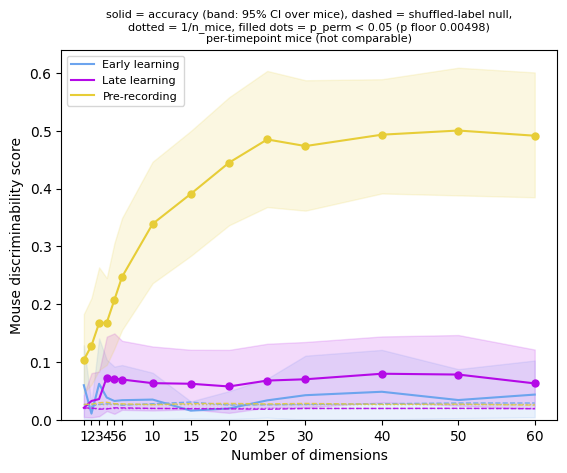

In [76]:
# --- Mouse discriminability across learning timepoints ---
# `labels` and `colors` come from TIMEPOINTS, so they follow USE_TIMEPOINTS automatically

x_min, x_max = np.min(n_components), np.max(n_components)

for d, name in enumerate(USE_TIMEPOINTS):
    if np.all(np.isnan(scores[d, :])):
        continue

    # Trial data has no dimensionality sweep -> single dot at x = number of trial features
    if d in feature_dims:
        plt.errorbar(feature_dims[d], scores[d, 0],
                     yerr=[[scores[d, 0] - score_ci_low[d, 0]],
                           [score_ci_high[d, 0] - scores[d, 0]]],
                     fmt='o', color=colors[d], capsize=3, label=labels[d])
        continue

    plt.plot(n_components, scores[d, :], color=colors[d], label=labels[d], linestyle='-')

    # Band = 95% CI over held-out mice (not the across-subsample spread)
    plt.fill_between(n_components,
                     score_ci_low[d, :],
                     score_ci_high[d, :],
                     color=colors[d], alpha=0.15)

    # Empirical null: LDA fit to shuffled training labels, same colour, dashed.
    # This is the chance level to report -- it absorbs finite-sample bias that the
    # analytic 1/n_classes does not.
    plt.plot(n_components, shuffle_scores[d, :], color=colors[d],
             linestyle='dashed', linewidth=1, alpha=0.9)

    # Mark the sweep points that beat their own shuffled null
    sig = p_perm[d, :] < 0.05
    if np.any(sig):
        plt.plot(np.array(n_components)[sig], scores[d, :][sig], 'o',
                 color=colors[d], ms=5)

# Analytic chance, 1 / (number of mice classified in that dataset). Verified to be
# the correct value: every test session belongs to a mouse the LDA was trained on.
# With a common cohort this is one shared line, since every timepoint scores the same mice.
for d in range(len(USE_TIMEPOINTS)):
    if np.all(np.isnan(scores[d, :])) or np.isnan(n_mice_per_dataset[d]):
        continue
    plt.hlines(1 / n_mice_per_dataset[d], x_min, x_max, colors=colors[d],
               linestyles='dotted', linewidth=1, alpha=0.7)

cohort_note = (f'same {len(cohort)} mice at every timepoint'
               if cohort is not None else 'per-timepoint mice (not comparable)')

plt.xticks(np.array(n_components).astype(int))
plt.ylim(bottom=0)
plt.xlabel('Number of dimensions')
plt.ylabel('Mouse discriminability score')
plt.title('solid = accuracy (band: 95% CI over mice), dashed = shuffled-label null,\n'
          f'dotted = 1/n_mice, filled dots = p_perm < 0.05 (p floor {p_floor:.3g})\n'
          f'{cohort_note}',
          fontsize=8)
plt.legend(fontsize=8)
plt.show()

In [77]:
# --- Numbers behind the figure ---
if cohort is not None:
    print(f"Common cohort ({len(cohort)} mice present at all of {USE_TIMEPOINTS}):")
    print("  " + ", ".join(cohort))
else:
    print("Per-timepoint mice -- scores below are NOT comparable across timepoints")

for d, name in enumerate(USE_TIMEPOINTS):
    if np.all(np.isnan(scores[d, :])):
        continue
    print(f"\n{labels[d]}  ({int(n_mice_per_dataset[d])} mice, "
          f"analytic chance {1/n_mice_per_dataset[d]:.3f})")
    print(f"  (permutation p-value floor: {p_floor:.4g})")
    print(f"  {'nPC':>4s} {'acc':>6s} {'95% CI over mice':>18s} {'null':>6s} {'p_perm':>7s}")
    for b, npc in enumerate(n_components):
        if np.isnan(scores[d, b]):
            continue
        print(f"  {npc:4d} {scores[d, b]:6.3f} "
              f"[{score_ci_low[d, b]:6.3f},{score_ci_high[d, b]:6.3f}] "
              f"{shuffle_scores[d, b]:6.3f} {p_perm[d, b]:7.3f}")

Per-timepoint mice -- scores below are NOT comparable across timepoints

Early learning  (37 mice, analytic chance 0.027)
  (permutation p-value floor: 0.004975)
   nPC    acc   95% CI over mice   null  p_perm
     1  0.060 [ 0.001, 0.129]  0.026   0.080
     2  0.011 [ 0.000, 0.028]  0.023   0.577
     3  0.062 [ 0.001, 0.141]  0.026   0.080
     4  0.038 [ 0.000, 0.104]  0.027   0.289
     5  0.032 [ 0.000, 0.092]  0.027   0.234
     6  0.034 [ 0.000, 0.095]  0.025   0.194
    10  0.035 [ 0.001, 0.081]  0.028   0.229
    15  0.016 [ 0.002, 0.032]  0.031   0.791
    20  0.019 [ 0.001, 0.049]  0.025   0.687
    25  0.034 [ 0.004, 0.071]  0.026   0.184
    30  0.042 [ 0.000, 0.111]  0.026   0.249
    40  0.048 [ 0.000, 0.121]  0.028   0.303
    50  0.034 [ 0.003, 0.088]  0.029   0.289
    60  0.044 [ 0.004, 0.102]  0.029   0.284

Late learning  (49 mice, analytic chance 0.020)
  (permutation p-value floor: 0.004975)
   nPC    acc   95% CI over mice   null  p_perm
     1  0.021 [ 0.005, 